In [1]:
# Data analysis libraries import ki
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Dataset load kiya
df = pd.read_csv("data.csv")

# First 5 rows check ki
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [3]:
# Total rows and columns check kiye
df.shape

(11914, 16)

In [4]:
# Dataset ke saare column names
df.columns

Index(['Make', 'Model', 'Year', 'Engine Fuel Type', 'Engine HP',
       'Engine Cylinders', 'Transmission Type', 'Driven_Wheels',
       'Number of Doors', 'Market Category', 'Vehicle Size', 'Vehicle Style',
       'highway MPG', 'city mpg', 'Popularity', 'MSRP'],
      dtype='str')

In [5]:
# Data types aur null values check ki
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  str    
 1   Model              11914 non-null  str    
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  str    
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  str    
 7   Driven_Wheels      11914 non-null  str    
 8   Number of Doors    11908 non-null  float64
 9   Market Category    8172 non-null   str    
 10  Vehicle Size       11914 non-null  str    
 11  Vehicle Style      11914 non-null  str    
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
dtypes: float64(3), int64(5), str(8)
m

In [6]:
# Missing values count ki
df.isnull().sum()

Make                    0
Model                   0
Year                    0
Engine Fuel Type        3
Engine HP              69
Engine Cylinders       30
Transmission Type       0
Driven_Wheels           0
Number of Doors         6
Market Category      3742
Vehicle Size            0
Vehicle Style           0
highway MPG             0
city mpg                0
Popularity              0
MSRP                    0
dtype: int64

In [ ]:
#Numeric columns → Median
df['Engine HP'] = df['Engine HP'].fillna(df['Engine HP'].median())

df['Engine Cylinders'] = df['Engine Cylinders'].fillna(df['Engine Cylinders'].median())

df['Number of Doors'] = df['Number of Doors'].fillna(df['Number of Doors'].median())

In [8]:
#Categorical columns → Mode
df['Market Category'] = df['Market Category'].fillna(df['Market Category'].mode()[0])

df['Engine Fuel Type'] = df['Engine Fuel Type'].fillna(df['Engine Fuel Type'].mode()[0])

In [9]:
# Duplicate rows check ki
df.duplicated().sum()

np.int64(715)

In [12]:
# Duplicate rows remove ki
df = df.drop_duplicates()
df.duplicated().sum()


np.int64(0)

In [13]:
# Dataset statistics
df.describe()

,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP
count,11199.000000,11199.000000,11199.000000,11199.000000,11199.000000,11199.000000,11199.000000,1.119900e+04
mean,2010.714528,253.226270,5.666845,3.454416,26.610590,19.731851,1558.483347,4.192593e+04
std,7.228211,109.830464,1.794696,0.872804,8.977641,9.177555,1445.668872,6.153505e+04
min,1990.000000,55.000000,0.000000,2.000000,12.000000,7.000000,2.000000,2.000000e+03
25%,2007.000000,172.000000,4.000000,2.000000,22.000000,16.000000,549.000000,2.159950e+04
50%,2015.000000,236.000000,6.000000,4.000000,25.000000,18.000000,1385.000000,3.067500e+04
75%,2016.000000,303.000000,6.000000,4.000000,30.000000,22.000000,2009.000000,4.303250e+04
max,2017.000000,1001.000000,16.000000,4.000000,354.000000,137.000000,5657.000000,2.065902e+06


In [14]:
# Numeric columns correlation
corr = df.corr(numeric_only=True)

corr

,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP
Year,1.000000,0.334828,-0.034152,0.247739,0.244972,0.188417,0.085874,0.209635
Engine HP,0.334828,1.000000,0.774943,-0.129554,-0.366345,-0.359215,0.041668,0.658536
Engine Cylinders,-0.034152,0.774943,1.000000,-0.149798,-0.596246,-0.562599,0.038325,0.538531
Number of Doors,0.247739,-0.129554,-0.149798,1.000000,0.115081,0.121013,-0.057213,-0.144353
highway MPG,0.244972,-0.366345,-0.596246,0.115081,1.000000,0.886299,-0.017159,-0.166631
city mpg,0.188417,-0.359215,-0.562599,0.121013,0.886299,1.000000,-0.000549,-0.162343
Popularity,0.085874,0.041668,0.038325,-0.057213,-0.017159,-0.000549,1.000000,-0.048371
MSRP,0.209635,0.658536,0.538531,-0.144353,-0.166631,-0.162343,-0.048371,1.000000


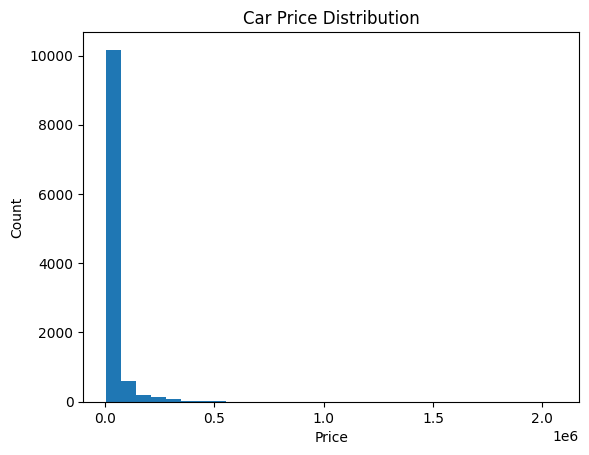

In [22]:
plt.hist(df['MSRP'], bins=30)

plt.title("Car Price Distribution")

plt.xlabel("Price")

plt.ylabel("Count")

plt.show()


#Price distribution pata chalta hai
#expensive cars identify hoti he

In [23]:
#Most common brands dataset me
df['Make'].value_counts().head(10)

Make
Chevrolet     1083
Ford           825
Toyota         719
Volkswagen     568
Nissan         551
Dodge          529
GMC            482
Honda          433
Mazda          412
Cadillac       396
Name: count, dtype: int64

In [25]:
#Most expensive brands identify karne ke liye
df.groupby('Make')['MSRP'].mean().sort_values(ascending=False).head(10)

Make
Bugatti         1.757224e+06
Maybach         5.462219e+05
Rolls-Royce     3.511306e+05
Lamborghini     3.315673e+05
Bentley         2.471693e+05
McLaren         2.398050e+05
Ferrari         2.382188e+05
Spyker          2.149900e+05
Aston Martin    1.981235e+05
Maserati        1.136845e+05
Name: MSRP, dtype: float64

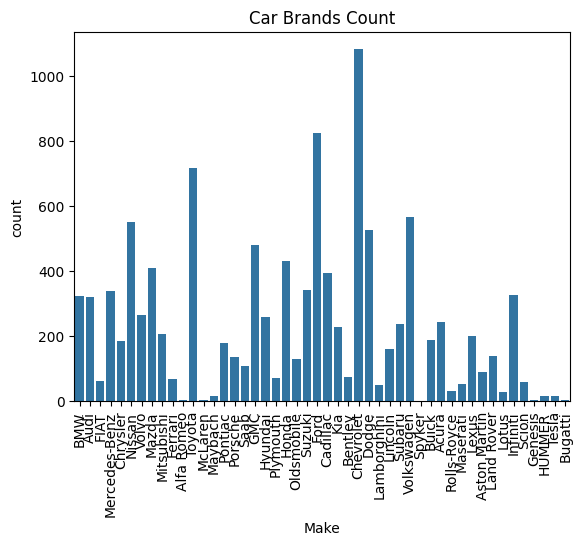

In [34]:
sns.countplot(x='Make', data=df)

plt.title("Car Brands Count")

plt.xticks(rotation=90)

plt.show()


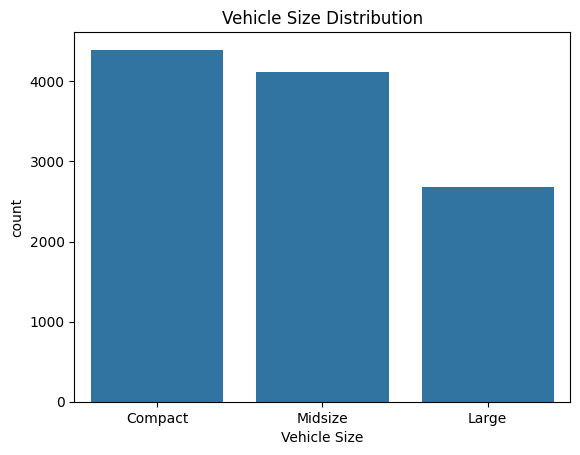

In [32]:
# vehicle ko size according distribution kiya
sns.countplot(x='Vehicle Size', data=df)

plt.title("Vehicle Size Distribution")

plt.show()

In [ ]:
sns.countplot(x='Transmission Type', data=df)

plt.title("Transmission Type")

plt.show()

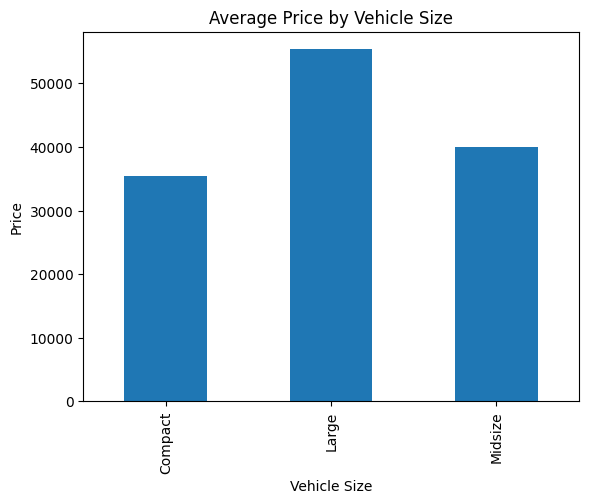

In [33]:
#Average Price by Vehicle Size
df.groupby('Vehicle Size')['MSRP'].mean().plot(kind='bar')

plt.title("Average Price by Vehicle Size")

plt.ylabel("Price")

plt.show()

In [ ]:
df.to_csv("cleaned_car_data.csv", index=False)
#Save Clean Dataset

In [ ]:
Final Simple Insights:

1. Dataset me 11914 rows aur 16 columns hain
2. Missing values ko median aur mode se fill kiya
3. Duplicate rows remove ki
️4. Most cars medium size vehicles hain
5. Automatic transmissionn ars jyada hain
6. Price distribution uneven hai (luxury cars high price)